# 8 — Classify the bursts, then analyse each group

*Series: **Bayesian fluorescence decays**, notebook 8 of 8. Builds §8.2 of
`THEORY.md`.*

**What this notebook establishes.** That a single-molecule measurement can be
analysed in two steps — group the bursts by what each one looks like, then run
the Bayesian decay analysis on each group — and that this separates
populations the pooled analysis cannot; together with what the step costs,
which is not nothing.

---

## Why this is possible at all

A pooled decay of every burst is a mixture, so the distance distribution has
to carry every population at once, and notebook 5 measured what that costs:
two populations closer than about 0.2 $R/R_0$ are not separated.

But each burst is **one molecule**, and it carries its own estimate of its own
distance. With $N$ photons,

$$
\sigma_{E^*}\approx\sqrt{\frac{E(1-E)}{N}},
\qquad
\sigma_{\langle t\rangle_D}\approx\frac{\tau}{\sqrt N},
$$

so a few hundred photons localise the efficiency to a few percent. That is far
too coarse to *place* a molecule — which is why the decay analysis exists —
but it is more than enough to *group* molecules.

And there are two independent handles, which is the point. $E^*$ is an
intensity ratio; $\langle t\rangle_D$, the mean arrival time of the donor
photons, is a clock. They measure the same distance by different physics, so
their errors are independent and the separation in the plane is better than in
either axis. $S$, the stoichiometry, separates the molecules whose acceptor
does not work at all.

## What the two steps are, as probability

Hard-assign each burst to a group $g$. The photon sets are then disjoint, so
the likelihood factorises and each group gets its own distribution while the
nuisances stay shared:

$$
\pi\big(\{p_g\},\theta_{\text{nuis}}\mid y\big)\;\propto\;
\prod_g L\big(y_g\mid p_g,\theta_{\text{nuis}}\big)\,
\prod_g \pi(p_g\mid\lambda_g)\,\pi(\theta_{\text{nuis}}).
$$

Each $p_g$ is much narrower than the pooled $p=\sum_g w_g p_g$, and a narrow
distribution is what the roughness prior and the resolution limit handle best.

**This is an approximation, and it is worth naming.** The assignment is hard,
so a burst put in the wrong group contributes its photons to the wrong
distribution. The clean version is a mixture model with soft responsibilities;
hard assignment is its zero-temperature limit.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd
bd.keep_inline()

S = bd.default_settings()
S.update(n_bursts=5000, n_bursts_donor=1500, threads=4, seed=41,
         photons_per_burst=200, burst_min_photons=60,
         species=[dict(R=48.0, fraction=0.5, width=3.0, name='high FRET'),
                  dict(R=58.0, fraction=0.5, width=3.0, name='low FRET')])
model = bd.build_model(S)
L, rel = model['L'], model['rel']
sep = abs(S['species'][0]['R'] - S['species'][1]['R']) / S['R0']
print(f"two populations at R/R0 {S['species'][0]['R']/S['R0']:.3f} and {S['species'][1]['R']/S['R0']:.3f}, "
      f'separation {sep:.3f}')
print('notebook 5 measured: separated sometimes at 0.20, never at 0.15 -- this is on that edge')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
two populations at R/R0 0.923 and 1.115, separation 0.192
notebook 5 measured: separated sometimes at 0.20, never at 0.15 -- this is on that edge


## The clustering, and the library it uses

HDBSCAN (Campello, Moulavi & Sander, PAKDD 2013) through **tttrlib's own
implementation**: the mutual-reachability minimum spanning tree, its condensed
tree, and the point labelling. tttrlib does not expose the cluster-*selection*
step, so that one piece — the excess-of-mass rule of the paper, and its leaf
variant — is written here and checked against `sklearn.cluster.HDBSCAN` on
data where the two could disagree.

That check is run first, because a clustering that has never been compared
with anything is not evidence. It found a real bug when it was written: the
first version let the root of the tree compete with its children, and since
the root holds every point its stability wins — one cluster containing the
whole sample.

In [2]:
rows = bd.check_hdbscan_selection()

  tttrlib labels every point; scikit-learn calls points outside the selected clusters noise,
  so "core" compares only the points scikit-learn does cluster.
  eom: 45 cases; core Rand min 0.9630, mean 0.9938; all points 0.9986; cluster count agrees in 15/45
     weakest: seed 3, blobs 1.0/0.5, min size 25 -- core Rand 0.963, 3 vs 2 clusters, sklearn noise 438
     weakest: seed 1, blobs 1.0/0.5, min size 25 -- core Rand 0.967, 3 vs 2 clusters, sklearn noise 403
  leaf: 45 cases; core Rand min 0.8843, mean 0.9903; all points 0.9936; cluster count agrees in 12/45
     weakest: seed 1, blobs 3.0/0.25, min size 15 -- core Rand 0.884, 5 vs 4 clusters, sklearn noise 145
     weakest: seed 4, blobs 1.0/0.5, min size 15 -- core Rand 0.958, 4 vs 3 clusters, sklearn noise 433


HDBSCAN is preferred to k-means here because the number of
populations is what one wants to learn rather than declare.

One choice has to be made and it is visible in the figure: **which clusters to
keep from the tree.** Excess of mass prefers a parent whenever the split
between its children is not a deep valley in density — and two FRET
populations whose per-burst observables overlap by a few standard deviations
are exactly that case, so it returns them merged. The leaf rule keeps every
leaf and separates them. Both are run below, on the same bursts, so the choice
is not hidden.

4581 bursts, median size 358 photons
per-burst precision at that size: sigma(E*) about 0.026

  eom: n=865 E*=0.05 S=1.00 <t>=8.67  |  n=3716 E*=0.55 S=0.70 <t>=7.04
 leaf: n=2613 E*=0.55 S=0.70 <t>=7.08  |  n=865 E*=0.05 S=1.00 <t>=8.67  |  n=578 E*=0.67 S=0.70 <t>=6.54  |  n=525 E*=0.45 S=0.69 <t>=7.42


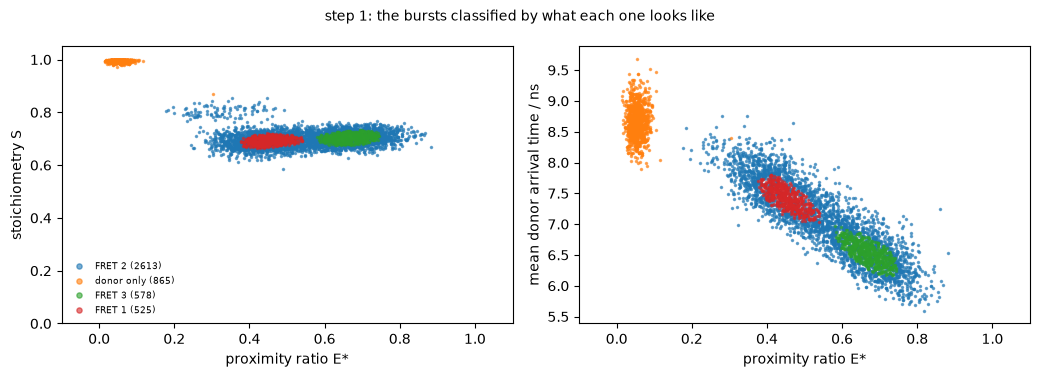

In [3]:
p_true = bd.truth_distribution(model, S)
tab = bd.physics_tables(model, S, p_true, verbose=False)
stream = bd.simulate_stream(model, S, p_true, tab)
tttr = {s: bd.to_tttr(model, d) for s, d in stream.items()}
sel, bursts = {}, {}
for s in ('DA', 'D0'):
    sel[s], bursts[s] = bd.burst_search(model, tttr[s], S)
feat = bd.burst_observables(tttr['DA'], bursts['DA'], model)
print(f"{len(bursts['DA'])} bursts, median size {np.median(feat[:,2]):.0f} photons")
print(f"per-burst precision at that size: sigma(E*) about {np.sqrt(0.25/np.median(feat[:,2])):.3f}\n")
for method in ('eom', 'leaf'):
    lab_ = bd.classify_bursts(feat, method=method)
    rr = bd.group_summary(feat, lab_)
    print(f'{method:>5}: ' + '  |  '.join(f"n={r['n']} E*={r['E']:.2f} S={r['S']:.2f} <t>={r['tau']:.2f}" for r in rr))
labels = bd.classify_bursts(feat, method='leaf')
rows_g = bd.group_summary(feat, labels)
names = bd.label_groups(rows_g)
fig = bd.plot_groups(feat, labels, names)

## What the groups actually are

The simulation knows which molecule made each burst, so the grouping can be
scored rather than admired. For each group: how many bursts, what the
classifier thought, and what the molecules behind those bursts really were.

In [4]:
truths = {}
print(f"{'group':<14}{'bursts':>8}{'photons':>10}{'E*':>7}{'S':>7}{'<t>/ns':>8}"
      f"{'true mean R/R0':>16}{'true width':>12}{'donor only':>12}")
for r in rows_g:
    sub = [b for b, l in zip(bursts['DA'], labels) if l == r['group']]
    p_g, x_g, cnt = bd.burst_truth(model, stream['DA'], tttr['DA'], sub)
    if cnt.sum() > 0:
        m_ = float((p_g * rel).sum()); s_ = float(np.sqrt((p_g * (rel - m_) ** 2).sum()))
    else:
        m_ = s_ = float('nan')
    truths[r['group']] = dict(p=p_g, x_d0=x_g, mean=m_, sd=s_, n=int(cnt.sum()))
    print(f"{names[r['group']]:<14}{r['n']:>8}{r['photons']:>10.0f}{r['E']:>7.2f}{r['S']:>7.2f}"
          f"{r['tau']:>8.2f}{m_:>16.3f}{s_:>12.3f}{x_g:>12.3f}")

group           bursts   photons     E*      S  <t>/ns  true mean R/R0  true width  donor only
FRET 2            2613   1003371   0.55   0.70    7.08           1.017       0.116       0.001
donor only         865    180591   0.05   1.00    8.67             nan         nan       1.000
FRET 3             578    224411   0.67   0.70    6.54           0.922       0.034       0.000
FRET 1             525    195688   0.45   0.69    7.42           1.102       0.040       0.000


## Step 3: the same Bayesian decay analysis, three times

Once, on every burst pooled — which is what notebook 7 did — and once on each
FRET group. The donor-only reference sample supplies the donor's decay in all
three, exactly as before. Nothing about the model changes; only which photons
go into the histograms.

In [5]:
y_d0 = bd.burst_decays(model, tttr['D0'], sel['D0'], 'D0')
fits = {}
t0 = time.time()
groups = [r['group'] for r in rows_g if names[r['group']].startswith('FRET')]
for tag, idx in [('pooled', sel['DA'])] + [(names[g], bd.group_indices(bursts['DA'], labels, g)) for g in groups]:
    y_t = bd.assemble_data(model, y_d0, bd.burst_decays(model, tttr['DA'], idx, 'DA'))
    nodes = [bd.fit_at_lambda(model, y_t, lg) for lg in (0.5, -0.5)]
    post = bd.mix_nodes(nodes)
    ref, ref_sd = bd.poisson_reference(post, 150, 3)
    fits[tag] = dict(post=post, y=y_t, ref=ref, ref_sd=ref_sd, n=len(idx))
    print(f'  {tag:<14} {len(idx):>8} photons, D/dof {post["dev"]/post["dof"]:.4f} '
          f'(reference {ref:.4f} +- {ref_sd:.4f}), {time.time()-t0:.0f} s total', flush=True)

  pooled          1620024 photons, D/dof 1.1054 (reference 1.0898 +- 0.0317), 51 s total


  FRET 2          1013250 photons, D/dof 1.1297 (reference 1.0915 +- 0.0362), 111 s total


  FRET 3           226485 photons, D/dof 1.1089 (reference 1.0938 +- 0.0368), 283 s total


  FRET 1           197647 photons, D/dof 1.1044 (reference 1.0988 +- 0.0370), 333 s total


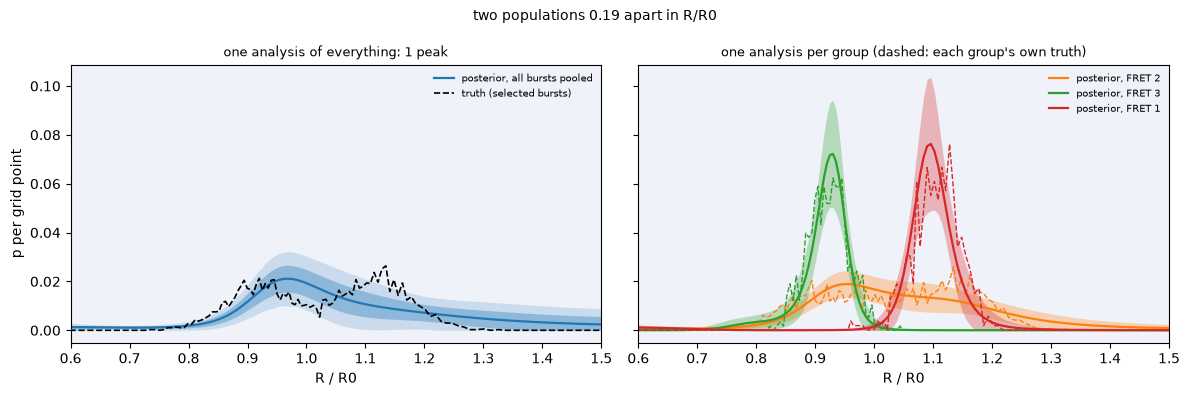

In [6]:
p_pool, x_pool, _ = bd.burst_truth(model, stream['DA'], tttr['DA'], bursts['DA'])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.0), sharey=True)
m = L.delta_bands(None, fits['pooled']['post'], rel, space='linear')
ax[0].fill_between(rel, m[3], m[4], color='C0', alpha=0.18, lw=0)
ax[0].fill_between(rel, m[1], m[2], color='C0', alpha=0.35, lw=0)
ax[0].plot(rel, m[0], 'C0', lw=1.6, label='posterior, all bursts pooled')
ax[0].plot(rel, p_pool, 'k--', lw=1.2, label='truth (selected bursts)')
inside = (rel > 0.6) & (rel < 1.5)
peaks_pool = int((np.diff(np.sign(np.diff(m[0][inside]))) < 0).sum())
ax[0].set_title(f'one analysis of everything: {peaks_pool} peak'
                + ('s' if peaks_pool != 1 else ''), fontsize=9)
for g, c in zip(groups, ('C1', 'C2', 'C3')):
    tag = names[g]
    mg = L.delta_bands(None, fits[tag]['post'], rel, space='linear')
    ax[1].fill_between(rel, mg[1], mg[2], color=c, alpha=0.3, lw=0)
    ax[1].plot(rel, mg[0], c, lw=1.6, label=f'posterior, {tag}')
    ax[1].plot(rel, truths[g]['p'], c, lw=1.0, ls='--')
ax[1].set_title('one analysis per group (dashed: each group\'s own truth)', fontsize=9)
for a in ax:
    a.set_xlabel('R / R0'); a.set_xlim(0.6, 1.5); L.shade_window(a, 0.01, label=False)
    a.legend(fontsize=7, frameon=False)
ax[0].set_ylabel('p per grid point')
fig.suptitle(f'two populations {sep:.2f} apart in R/R0', fontsize=10)
fig.tight_layout()

In [7]:
print(f"{'analysis':<16}{'truth mean':>12}{'posterior':>11}{'sd':>8}{'truth width':>13}{'posterior':>11}{'sd':>8}")
def report(tag, tr_p):
    post = fits[tag]['post']
    mu = float((tr_p * rel).sum()); sd = float(np.sqrt((tr_p * (rel - mu) ** 2).sum()))
    tr = dict(x_d0=0.0, mean=mu, sd=sd, tail=float(tr_p[rel > 1.3].sum()),
              r0_d=S['r0_donor'], r0_a=S['r0_acceptor'], g=L.S.G_TRUE)
    r = {x['quantity']: x for x in bd.summary_table(model, post, tr)}
    print(f"{tag:<16}{mu:>12.3f}{r['mean']['mean']:>11.3f}{r['mean']['sd']:>8.3f}"
          f"{sd:>13.3f}{r['sd']['mean']:>11.3f}{r['sd']['sd']:>8.3f}")
report('pooled', p_pool)
for g in groups:
    report(names[g], truths[g]['p'])
print('\nthe pooled width includes the separation of the two populations;')
print('each group\'s width is the population\'s own, which is what the experiment was for.')

analysis          truth mean  posterior      sd  truth width  posterior      sd
pooled                 1.014      1.030   0.030        0.111      0.168   0.058
FRET 2                 1.017      1.022   0.015        0.116      0.135   0.032
FRET 3                 0.922      0.918   0.002        0.034      0.043   0.017
FRET 1                 1.102      1.089   0.009        0.040      0.076   0.025

the pooled width includes the separation of the two populations;
each group's width is the population's own, which is what the experiment was for.


## What it bought, and what it cost

Read the group table and the figure together, because what happened is more
interesting than "it worked".

**The two populations were recovered, at a separation the pooled analysis
cannot resolve.** Pooled, the answer is one hump of width 0.168 against a true
0.111 — the width is dominated by the gap between the populations rather than
by either of them. The two small groups return means of 0.918 and 1.089
against truths of 0.922 and 1.102, with posterior standard deviations of 0.002
and 0.009. Those are the populations, separately, at a separation of 0.19
$R/R_0$.

**But the clustering did not split the sample in two. It split it in three.**
The leaf rule peeled off the two populations' non-overlapping wings — the
bursts whose observables are unambiguous — and left their overlapping core as
a third, larger group whose true width is 0.116, that is, still a mixture. The
group truths in the table say so plainly: 578 and 525 bursts of nearly pure
composition, and 2613 bursts that are both populations together.

That is the honest shape of the gain. Classification does not separate
populations; it separates *bursts*, and it separates cleanly only those
bursts that were far enough apart in the observables to begin with. What one
gets is not two clean halves but two clean margins and a mixed middle.

The costs, stated rather than buried:

**Misassignment and incompleteness.** The wings are nearly pure, which is why
their posteriors are so tight — but they are a minority of the molecules, and
a distribution estimated from them is a distribution of *the bursts that were
easy to classify*. Extrapolating it to the sample is an assumption, not a
measurement.

**A choice that is not the data's.** Excess of mass and the leaf rule give
different numbers of groups on the same bursts: two and four here. That choice
must be reported with the answer.

**The groups are not the populations.** They are groups of bursts defined by a
threshold in a plane of observables. Calling them populations is an
interpretation, and it is checkable here only because the simulation knows the
answer.

**And what does not change**: the decay analysis itself. The model, the prior,
the marginalisation over the penalty weight, the Laplace approximation, the
delta method and Rule 0 are exactly those of notebooks 3 to 6, applied to
whichever photons a step before them chose.

### A note on the library

The clustering above runs on tttrlib's HDBSCAN, with the cluster-selection
step supplied locally because tttrlib exposed the tree but not the selection.
That gap was reported, and tttrlib has since grown a complete `hdbscan` entry
point with membership strengths; the example prefers it when present, and the
outputs stored in this notebook were produced by the local fallback.

## Where the series ends

The final model is now completely specified, and every piece of it has a
reason recorded in the notebook that introduced it:

| | |
|---|---|
| Poisson likelihood, weighted by the model | 1 |
| basis with periodic convolution | 1 |
| distribution on a grid, linear in the amplitudes | 1 |
| spline in $\log p$ with a difference penalty | 2 |
| the penalty weight integrated, not maximised | 3 |
| evidence mixture over the weight's grid | 3 |
| delta-method summaries and bands in $p$ | 4 |
| deviance against a measured reference, runs test, rank calibration | 5 |
| interleaved excitation, and reference samples under both lasers | 6 |
| burst photons rather than a cuvette | 7 |
| classification before pooling | 8 |

`../smfret_pie_mfd` is the whole of it as one runnable example.